In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter

In [2]:
df_d = pd.read_csv("../data/publication_output/dataset/survival_feature_matrix.csv")
df_m = pd.read_csv("../data/publication_output/d_mannheim/survival_feature_matrix.csv")


In [13]:
total_per_quarter = df_d.groupby('quarters').size()
label_1_per_quarter = df_d[df_d['label'] == 1].groupby('quarters').size()
label_0_per_quarter = df_d[df_d['label'] == 0].groupby('quarters').size()

# Fill missing quarters with 0 and align the indices
label_1_per_quarter = label_1_per_quarter.reindex(total_per_quarter.index, fill_value=0)
label_0_per_quarter = label_0_per_quarter.reindex(total_per_quarter.index, fill_value=0)

samples_per_quarter_d = total_per_quarter.tolist()
samples_label_1_per_quarter_d = label_1_per_quarter.tolist()
samples_label_0_per_quarter_d = label_0_per_quarter.tolist()

samples_per_quarter_d, samples_label_1_per_quarter_d, samples_label_0_per_quarter_d

([507,
  475,
  437,
  405,
  358,
  323,
  321,
  284,
  268,
  240,
  216,
  193,
  185,
  170,
  165,
  157,
  151,
  123,
  122,
  118,
  111,
  99,
  89,
  93,
  79,
  78,
  65,
  64,
  69,
  55,
  65,
  60],
 [207,
  183,
  164,
  122,
  105,
  92,
  91,
  84,
  80,
  70,
  59,
  45,
  30,
  35,
  30,
  34,
  35,
  34,
  28,
  24,
  21,
  20,
  14,
  14,
  12,
  8,
  5,
  3,
  8,
  7,
  6,
  8],
 [300,
  292,
  273,
  283,
  253,
  231,
  230,
  200,
  188,
  170,
  157,
  148,
  155,
  135,
  135,
  123,
  116,
  89,
  94,
  94,
  90,
  79,
  75,
  79,
  67,
  70,
  60,
  61,
  61,
  48,
  59,
  52])

In [14]:
total_per_quarter = (df_m.groupby('quarters').size())
label_1_per_quarter = df_m[df_m['label'] == 1].groupby('quarters').size()
label_0_per_quarter = df_m[df_m['label'] == 0].groupby('quarters').size()

# Fill missing quarters with 0 and align the indices
label_1_per_quarter = label_1_per_quarter.reindex(total_per_quarter.index, fill_value=0)
label_0_per_quarter = label_0_per_quarter.reindex(total_per_quarter.index, fill_value=0)

samples_per_quarter_m = total_per_quarter.tolist()
samples_label_1_per_quarter_m = label_1_per_quarter.tolist()
samples_label_0_per_quarter_m = label_0_per_quarter.tolist()

samples_per_quarter_m, samples_label_1_per_quarter_m, samples_label_0_per_quarter_m

([10,
  12,
  9,
  12,
  13,
  13,
  12,
  13,
  12,
  12,
  10,
  11,
  9,
  9,
  9,
  6,
  6,
  5,
  5,
  6,
  5,
  4,
  2,
  4,
  3,
  4,
  4,
  4,
  4,
  4,
  5,
  5],
 [4,
  4,
  2,
  2,
  2,
  0,
  1,
  1,
  2,
  2,
  2,
  2,
  1,
  0,
  0,
  0,
  1,
  1,
  1,
  2,
  1,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 [6,
  8,
  7,
  10,
  11,
  13,
  11,
  12,
  10,
  10,
  8,
  9,
  8,
  9,
  9,
  6,
  5,
  4,
  4,
  4,
  4,
  3,
  2,
  4,
  3,
  4,
  4,
  4,
  4,
  4,
  5,
  5])

In [5]:
# stability over time plots heidelberg
quarter = list(range(1,33))
ratio = []
samples = []
pos_samples = []
neg_samples = []

values = """
Length: 1 quarters
Ratio: 0.3611111111111111
Samples: 180, positive samples: 65
GBM metrics: 0.8109698996655519, 0.6798289183194148, 0.1768048055598699
GBM_baseline metrics: 0.8044147157190635, 0.6497979466737525, 0.214809800760046
Length: 2 quarters
Ratio: 0.3563218390804598
Samples: 174, positive samples: 62
GBM metrics: 0.8667914746543779, 0.8183532631631522, 0.14997053812868488
GBM_baseline metrics: 0.7758496543778801, 0.6810608274000072, 0.2153834140509265
Length: 3 quarters
Ratio: 0.3125
Samples: 144, positive samples: 45
GBM metrics: 0.8464646464646465, 0.7516944804486868, 0.16427879358534261
GBM_baseline metrics: 0.7408529741863075, 0.5577936037650733, 0.22761644508444176
Length: 4 quarters
Ratio: 0.288
Samples: 125, positive samples: 36
GBM metrics: 0.9013732833957552, 0.8276204739871945, 0.13777820638622304
GBM_baseline metrics: 0.7348626716604245, 0.5227792258744598, 0.22169259301335467
Length: 5 quarters
Ratio: 0.28440366972477066
Samples: 109, positive samples: 31
GBM metrics: 0.8593879239040529, 0.7778002985982224, 0.14650821848547058
GBM_baseline metrics: 0.6885856079404467, 0.4804965238657496, 0.2233582228608469
Length: 6 quarters
Ratio: 0.2631578947368421
Samples: 95, positive samples: 25
GBM metrics: 0.9188571428571429, 0.8543949529754253, 0.10807620315772952
GBM_baseline metrics: 0.6837142857142858, 0.47198853399582275, 0.2147249247135027
Length: 7 quarters
Ratio: 0.275
Samples: 80, positive samples: 22
GBM metrics: 0.8973354231974922, 0.8576778323740458, 0.11009394247729051
GBM_baseline metrics: 0.7049373040752351, 0.5574225896277036, 0.21246178657432985
Length: 8 quarters
Ratio: 0.2597402597402597
Samples: 77, positive samples: 20
GBM metrics: 0.8842105263157894, 0.8526846407826119, 0.10973487429565726
GBM_baseline metrics: 0.6403508771929824, 0.4153629907058264, 0.228110332434323
Length: 9 quarters
Ratio: 0.18571428571428572
Samples: 70, positive samples: 13
GBM metrics: 0.8920377867746289, 0.7521054367029598, 0.10178727476858962
GBM_baseline metrics: 0.7172739541160594, 0.3804497544523011, 0.20590233647065834
Length: 10 quarters
Ratio: 0.23214285714285715
Samples: 56, positive samples: 13
GBM metrics: 0.8372093023255814, 0.7594152988813443, 0.1302172323878237
GBM_baseline metrics: 0.7495527728085867, 0.4296070004696483, 0.21841927551326126
Length: 11 quarters
Ratio: 0.1509433962264151
Samples: 53, positive samples: 8
GBM metrics: 0.625, 0.374732905982906, 0.1592020629360493
GBM_baseline metrics: 0.7597222222222222, 0.3344935254803676, 0.2118059300350097
Length: 12 quarters
Ratio: 0.16666666666666666
Samples: 48, positive samples: 8
GBM metrics: 0.7625000000000001, 0.5697614442295293, 0.15860385529740506
GBM_baseline metrics: 0.771875, 0.33970884439634436, 0.19289018589495655
Length: 13 quarters
Ratio: 0.2553191489361702
Samples: 47, positive samples: 12
GBM metrics: 0.7023809523809524, 0.5359220387729159, 0.19281551076018594
GBM_baseline metrics: 0.7226190476190476, 0.47920227920227926, 0.19228878593313484
Length: 14 quarters
Ratio: 0.1875
Samples: 32, positive samples: 6
GBM metrics: 0.7564102564102564, 0.5534722222222221, 0.16485759114348525
GBM_baseline metrics: 0.7019230769230769, 0.3461233211233211, 0.17589856233181422
Length: 15 quarters
Ratio: 0.21621621621621623
Samples: 37, positive samples: 8
GBM metrics: 0.6293103448275862, 0.40415023484579937, 0.19481872532244654
GBM_baseline metrics: 0.7155172413793103, 0.5172514619883041, 0.18857065824866712
Length: 16 quarters
Ratio: 0.2
Samples: 30, positive samples: 6
GBM metrics: 0.8263888888888888, 0.7093406593406593, 0.15879044562024933
GBM_baseline metrics: 0.6319444444444445, 0.33949579831932775, 0.19487684339530603
Length: 17 quarters
Ratio: 0.09090909090909091
Samples: 33, positive samples: 3
GBM metrics: 0.811111111111111, 0.48333333333333334, 0.12556897723271931
GBM_baseline metrics: 0.8277777777777777, 0.5111111111111111, 0.15148255829413051
Length: 18 quarters
Ratio: 0.06896551724137931
Samples: 29, positive samples: 2
GBM metrics: 0.5740740740740741, 0.54, 0.1698525798997528
GBM_baseline metrics: 0.8518518518518519, 0.26666666666666666, 0.1688288868837788
Length: 19 quarters
Ratio: 0.037037037037037035
Samples: 27, positive samples: 1
GBM metrics: 1.0, 1.0, 0.12839011679521803
GBM_baseline metrics: 0.8461538461538461, 0.2, 0.14853522514421408
Length: 20 quarters
Ratio: 0.12
Samples: 25, positive samples: 3
GBM metrics: 0.6515151515151515, 0.2383838383838384, 0.1719616873974255
GBM_baseline metrics: 0.7348484848484849, 0.2777777777777778, 0.15593534078611634
Length: 21 quarters
Ratio: 0.14814814814814814
Samples: 27, positive samples: 4
GBM metrics: 0.6521739130434783, 0.2638888888888889, 0.18760428913514243
GBM_baseline metrics: 0.625, 0.22574786324786325, 0.17254461381216005
Length: 22 quarters
Ratio: 0.2
Samples: 25, positive samples: 5
GBM metrics: 0.8099999999999999, 0.6502506265664161, 0.13025038168393316
GBM_baseline metrics: 0.565, 0.23929971988795518, 0.17812430600136722
Length: 23 quarters
Ratio: 0.25
Samples: 24, positive samples: 6
GBM metrics: 0.8148148148148149, 0.6825396825396826, 0.14677447096848406
GBM_baseline metrics: 0.662037037037037, 0.3543650793650793, 0.20108595957880723
Length: 24 quarters
Ratio: 0.18518518518518517
Samples: 27, positive samples: 5
GBM metrics: 0.8, 0.6291666666666667, 0.1369620693397582
GBM_baseline metrics: 0.5863636363636364, 0.24016659295297066, 0.1685354788584492
Length: 25 quarters
Ratio: 0.15789473684210525
Samples: 19, positive samples: 3
GBM metrics: 0.875, 0.7777777777777777, 0.10328264310030381
GBM_baseline metrics: 0.5, 0.1987012987012987, 0.15769640730892553
Length: 26 quarters
Ratio: 0.16666666666666666
Samples: 18, positive samples: 3
GBM metrics: 0.8444444444444444, 0.6666666666666666, 0.12511593529038956
GBM_baseline metrics: 0.4666666666666666, 0.19761904761904764, 0.16919655104930195
Length: 27 quarters
Ratio: 0.13636363636363635
Samples: 22, positive samples: 3
GBM metrics: 0.7017543859649122, 0.5254901960784314, 0.12778178752574282
GBM_baseline metrics: 0.631578947368421, 0.22222222222222224, 0.142016608423807
Length: 28 quarters
Ratio: 0.25
Samples: 16, positive samples: 4
GBM metrics: 0.6875, 0.5492424242424242, 0.18119453827969895
GBM_baseline metrics: 0.6666666666666666, 0.36964285714285716, 0.18700280328119923
Length: 29 quarters
Ratio: 0.17647058823529413
Samples: 17, positive samples: 3
GBM metrics: 0.7380952380952381, 0.3472222222222222, 0.13264778608182523
GBM_baseline metrics: 0.738095238095238, 0.3416666666666667, 0.14010774647060867
Length: 30 quarters
Ratio: 0.2
Samples: 15, positive samples: 3
GBM metrics: 0.9166666666666666, 0.8333333333333333, 0.10066429169216709
GBM_baseline metrics: 0.7500000000000001, 0.3873015873015873, 0.14673456422144907
Length: 31 quarters
Ratio: 0.23076923076923078
Samples: 13, positive samples: 3
GBM metrics: 1.0, 1.0, 0.08189856220236183
GBM_baseline metrics: 0.7333333333333333, 0.42063492063492064, 0.16841794380081906
Length: 32 quarters
Ratio: 0.14285714285714285
Samples: 14, positive samples: 2
GBM metrics: 1.0, 1.0, 0.08637668961856895
GBM_baseline metrics: 0.6666666666666666, 0.26785714285714285, 0.125715941433564
"""

for value in values.split("\n"):
    if value.startswith("Ratio:"):
        ratio.append(float(value[7:]))
    elif value.startswith("Samples:"):
        trimmed_values = value.split(", ")
        s = int(trimmed_values[0].split(": ")[1])
        ps = int(trimmed_values[1].split(": ")[1])
        samples.append(s)
        pos_samples.append(ps)
        neg_samples.append(s-ps)


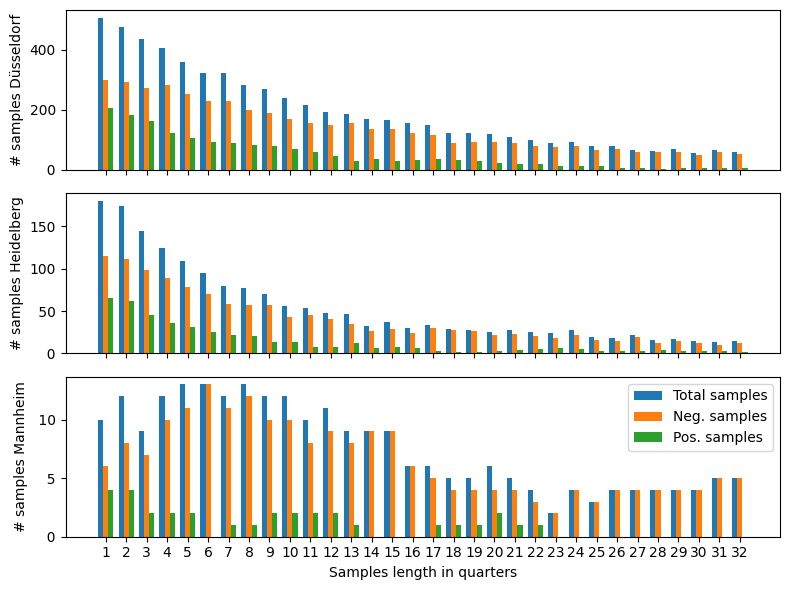

In [25]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(8,6), sharex=True)

def format_y_tick(val, _):
    return f"{int(val):>3}"  # right-aligned, 3-character-wide integer
formatter = FuncFormatter(format_y_tick)

models = [("Düsseldorf", samples_per_quarter_d, samples_label_0_per_quarter_d, samples_label_1_per_quarter_d),
          ("Heidelberg", samples, neg_samples, pos_samples),
          ("Mannheim", samples_per_quarter_m, samples_label_0_per_quarter_m, samples_label_1_per_quarter_m)
          ]

x = np.arange(0, 32)  # the label locations
xl = np.arange(1, 33)  # the label locations
width = 0.25  # the width of the bars

for ax, model in zip(axes, models):
    # Plot each bar with an offset
    ax.bar(x - width, model[1], width, label='Total samples')
    ax.bar(x, model[2], width, label='Neg. samples')
    ax.bar(x + width, model[3], width, label='Pos. samples')
    ax.set_ylabel(f'# samples {model[0]}')
    ax.yaxis.set_major_formatter(formatter)

# Formatting
plt.xticks(x, xl)
plt.xlabel("Samples length in quarters")
plt.legend()
plt.tight_layout()
plt.savefig("samples_over_time.svg")
plt.show()